# **Linear Discriminant Analysis (LDA)**

[LDA](https://en.wikipedia.org/wiki/Linear_discriminant_analysis) es un **método supervisado** para la reducción de la dimensionalidad en los datos. Puede ser utilizado para encontrar una combinación lineal de características que caracteriza o separa dos o más clases de objetos. La combinación resultante puede ser utilizada como un clasificador lineal, o, más comúnmente, para la reducción de la dimensionalidad antes de una clasificación posterior. LDA utiliza variables independientes continuas y una variable dependiente categórica, en contraste con el método ANOVA, que utiliza variables independientes categóricas y una variable dependiente continua.

LDA está estrechamente relacionado con el análisis de componentes principales (PCA), ambos buscan combinaciones lineales de variables que mejor expliquen los datos. LDA intenta explícitamente modelar la diferencia entre las clases de datos. PCA, en contraste, no toma en cuenta ninguna diferencia de clase, y el análisis factorial construye las combinaciones de características basándose en diferencias en lugar de similitudes.





- LDA es un metodo supervisado a diferencia de PCA que es no supervisado
- Lo que va buscando LDA es sacar componentes principales. Estas componentes principales a diferencia de PCA, su funcion no es explicar la información contenida en el dataset. Estas componentes principales estan optimizadas para separar las diferentes clases que puedan haber dentro de un dataset.


LDA (Análisis Discriminante Lineal) es un método supervisado que utiliza la información de las etiquetas de clase para encontrar las proyecciones que maximizan la separabilidad entre ellas. Para ello, LDA calcula dos matrices:

- Dispersion intra-clase (Within-class scatter, S<sub>w</sub>): Representa la variabilidad de los datos dentro de cada clase.
- Dispersion entre-clases (Between-class scatter, S<sub>b</sub>): Mide la separación entre las medias de las clases.

El objetivo de LDA es encontrar una transformación que maximice la razón entre la dispersión entre clases y la dispersión intra-clase

### **Import libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# upload files from your local machine
from google.colab import files
#files.upload()
df_wine = pd.read_excel('/content/1-Wine_data.xlsx')    # UCI repository wine data set   (https://archive.ics.uci.edu/ml/datasets/wine )
X = df_wine.iloc[:, 0:13].values
y = df_wine.iloc[:, 13].values

In [ ]:
df_wine.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
 13  Origin                178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [ ]:
df_wine.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Origin
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1


split both datasets, fetatures and labels, in training and testing sets:

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

Normalice features dataset:

In [ ]:
from sklearn.preprocessing import StandardScaler

# normalize features dataset
X_sc=StandardScaler()
X_train = X_sc.fit_transform(X_train)
X_test= X_sc.transform(X_test)

Apply LDA:

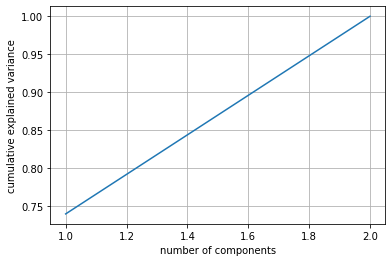

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda_wine = LinearDiscriminantAnalysis(n_components = 2)
lda_wine = lda_wine.fit(X_train, y_train)
cum_expvar = np.cumsum(lda_wine.explained_variance_ratio_)
plt.plot(range(1,len(cum_expvar)+1),cum_expvar)
plt.grid()
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance');

From the figure it is clear that 2 components provide 100% of the variance. Let's double-check it:

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda_wine = LinearDiscriminantAnalysis(n_components = 2)
wine_lda_projected_train = lda_wine.fit_transform (X_train, y_train)
wine_lda_projected_test = lda_wine.transform(X_test)

Train a classifier for the reduced datasets, and compare the classifiers performmances:


In [ ]:
# Create a LogisticRegression object
from sklearn.linear_model import LogisticRegression
classifierLogREg = LogisticRegression(random_state = 0)
classifierLogREg.fit(wine_lda_projected_train, y_train)

LogisticRegression(random_state=0)

(1166171, 2)
(971, 1201)


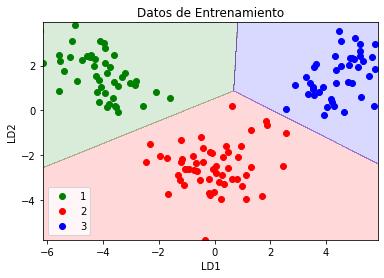

In [ ]:
# Plotting the meshgrid
from matplotlib.colors import ListedColormap
X_set = wine_lda_projected_train
y_set =  y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min()+0.1, stop = X_set[:, 0].max()+0.1 , step = 0.01),
                     np.arange(start = X_set[:, 1].min()+0.0 , stop = X_set[:, 1].max()+0.1 , step = 0.01))
X_meshgrid=np.array([X1.ravel(), X2.ravel()]).T
print(X_meshgrid.shape)
print(X1.shape)

plt.contourf(X1, X2, classifierLogREg.predict(X_meshgrid).reshape(X1.shape),
             alpha = 0.15, cmap = ListedColormap(('green', 'red', 'blue')))

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())


# Plotting the training data results
for  i,j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('green' , 'red', 'blue'))(i), label = j)
plt.title('Datos de Entrenamiento')
plt.xlabel('LD1')

plt.ylabel('LD2')

plt.legend()
plt.show()




(1095248, 2)
(889, 1232)


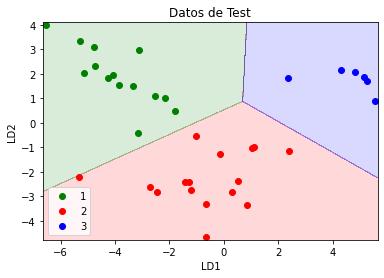

In [ ]:
# Plotting the meshgrid
from matplotlib.colors import ListedColormap
X_set = wine_lda_projected_test
y_set =  y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min()-0.1, stop = X_set[:, 0].max()+0.1 , step = 0.01),
                     np.arange(start = X_set[:, 1].min()-0.1 , stop = X_set[:, 1].max()+0.1 , step = 0.01))
X_meshgrid=np.array([X1.ravel(), X2.ravel()]).T
print(X_meshgrid.shape)
print(X1.shape)

plt.contourf(X1, X2, classifierLogREg.predict(X_meshgrid).reshape(X1.shape),
             alpha = 0.15, cmap = ListedColormap(('green', 'red', 'blue')))

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

# Plotting the training data results
for  i,j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('green' , 'red', 'blue'))(i), label = j)
plt.title('Datos de Test')
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.legend()
plt.show()



In [ ]:
y_pred=classifierLogREg.predict(wine_lda_projected_test)

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print (cm)

[[14  0  0]
 [ 0 16  0]
 [ 0  0  6]]
